# 💰 Modelo de Costos y Rentabilidad

## Contexto
Con el dataset limpio de precios de mercado, construí un modelo económico que calcula
la **ganancia neta mensual** de un conductor de Cabify para cada auto analizado.

## Fuentes de los parámetros
- **Ingresos brutos:** relevamiento de iProfesional a más de 25 choferes activos en AMBA (2025).
  Un conductor trabajando jornada completa (8hs, lunes a sábado) genera entre $1.600.000
  y $2.400.000 brutos mensuales. Usé el valor medio de $2.000.000.
- **Comisión Cabify:** 12,5% oficial para viajes de usuarios privados en GBA.
- **Tipo de cambio:** scrapeado en tiempo real desde dolarhoy.com (dólar blue, venta).
  Uso el blue porque el mercado de autos usados en Argentina se referencia al dólar libre.

## Fórmula central del modelo
```
Ganancia Neta = Ingresos Brutos
              - Comisión Cabify (12.5%)
              - Combustible mensual
              - Amortización del vehículo
              - Seguro
              - Patente prorrateada
```

### Parámetros y función de rentabilidad

El modelo está implementado en `src/modelo.py` como una función pura que recibe
el precio de compra del auto y su consumo, y devuelve un diccionario con todos
los componentes del cálculo desagregados.

**Decisión de diseño:** separé el modelo en `src/` y no en el notebook porque
es código reutilizable — lo voy a llamar desde la simulación de Montecarlo también.
Mezclar lógica de negocio con presentación en un notebook es mala práctica.

In [4]:
import pandas as pd
import requests
import sys
from bs4 import BeautifulSoup
sys.path.append("..")
from src.modelo import calcular_rentabilidad, PARAMETROS

df = pd.read_csv("../data/processed/precios_autos_procesado.csv")

def get_tipo_cambio():
    url = "https://dolarhoy.com/"
    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(url, headers=headers, timeout=10)
    soup = BeautifulSoup(response.text, "html.parser")
    valores = soup.find_all("div", class_="val")
    venta_blue = valores[5].text.strip().replace("$", "").replace(".", "").replace(",", ".")
    return float(venta_blue)

TIPO_CAMBIO = get_tipo_cambio()
print(f"Tipo de cambio: ${TIPO_CAMBIO:,.0f} ARS/USD")
print(f"Parámetros del modelo:\n{PARAMETROS}")

Tipo de cambio: $1,420 ARS/USD
Parámetros del modelo:
{'ingreso_bruto_mensual_ars': 2000000, 'comision_cabify': 0.125, 'km_diarios': 150, 'dias_laborales_mes': 26, 'precio_nafta_ars_litro': 1100, 'precio_gnc_ars_m3': 280, 'seguro_mensual_ars': 180000, 'patente_anual_ars': 400000, 'vida_util_km': 300000}


### Datos técnicos de consumo por modelo

Para calcular el costo de combustible necesito el consumo en L/100km de cada auto.
Estos datos provienen de las fichas técnicas oficiales de cada fabricante,
contrastadas con relevamientos de consumo real en ciudad de foros especializados
(Autocosmos, Club del auto). Uso el consumo en ciudad porque un chofer de Cabify
opera principalmente en zona urbana.

### Resultados del modelo

Aplico el modelo a cada auto usando el **precio mediano** del mercado como
precio de compra. Uso la mediana y no el promedio porque es más robusta ante
valores extremos — el 50% de las publicaciones están por debajo de ese precio,
lo que representa una compra realista para un conductor promedio.

In [5]:
# Datos técnicos de consumo por modelo (L/100km en ciudad, fuente: fichas técnicas)
consumo_por_modelo = {
    "Toyota Etios":      8.5,
    "Toyota Corolla":    9.0,
    "Toyota Yaris":      8.0,
    "Chevrolet Prisma":  8.5,
    "Renault Logan":     8.0,
    "Nissan Versa":      9.0,
    "VW Virtus":         8.5,
    "VW Voyage":         9.5,
    "VW Gol":            9.0,
    "Ford Ka":           8.0,
    "Ford Fiesta":       9.0,
    "Fiat Siena":        9.5,
    "Peugeot 208":       7.5,
}

# GNC disponible para estos modelos (mercado de usados con equipo instalado)
tiene_gnc = {
    "Toyota Etios":      False,
    "Toyota Corolla":    False,
    "Toyota Yaris":      False,
    "Chevrolet Prisma":  True,
    "Renault Logan":     True,
    "Nissan Versa":      False,
    "VW Virtus":         False,
    "VW Voyage":         True,
    "VW Gol":            True,
    "Ford Ka":           False,
    "Ford Fiesta":       False,
    "Fiat Siena":        True,
    "Peugeot 208":       False,
}

# Precio mediano por modelo desde el dataset
precio_mediano = df.groupby("modelo")["precio_usd"].median()

# Aplicar modelo a cada auto
resultados = []
for modelo in consumo_por_modelo:
    precio = precio_mediano[modelo]
    resultado = calcular_rentabilidad(
        precio_compra_usd=precio,
        consumo_l_100km=consumo_por_modelo[modelo],
        tiene_gnc=tiene_gnc[modelo],
        tipo_cambio=TIPO_CAMBIO
    )
    resultado["modelo"] = modelo
    resultado["tiene_gnc"] = tiene_gnc[modelo]
    resultados.append(resultado)

df_resultados = pd.DataFrame(resultados).set_index("modelo")

# Mostrar tabla resumen
cols_mostrar = ["precio_compra_usd", "ganancia_neta_usd", "ganancia_neta_ars",
                "payback_meses", "costo_combustible_ars", "amortizacion_mensual_ars"]

print(df_resultados[cols_mostrar].sort_values("ganancia_neta_usd", ascending=False).to_string())

                  precio_compra_usd  ganancia_neta_usd  ganancia_neta_ars  payback_meses  costo_combustible_ars  amortizacion_mensual_ars
modelo                                                                                                                                   
VW Gol                  6126.760563         925.610329       1.314367e+06       6.619158               109200.0                  113100.0
Fiat Siena              7605.633803         906.384977       1.287067e+06       8.391174               109200.0                  140400.0
VW Voyage               8450.000000         895.408216       1.271480e+06       9.437036               109200.0                  155987.0
Chevrolet Prisma       10105.633803         873.884977       1.240917e+06      11.564032               109200.0                  186550.0
Renault Logan          11197.183099         859.694836       1.220767e+06      13.024602               109200.0                  206700.0
Ford Fiesta             6683.09859

### ⚠️ Supuesto asumido: mantenimiento de equipo GNC

Los autos con GNC en el dataset son unidades usadas que ya tienen el equipo instalado.
El costo del equipo está implícitamente absorbido en el precio de compra de mercado.

Lo que el modelo **no incluye** es el mantenimiento periódico del equipo GNC:
- Revisión obligatoria cada 2 años
- Cambio de válvulas y mangueras según km

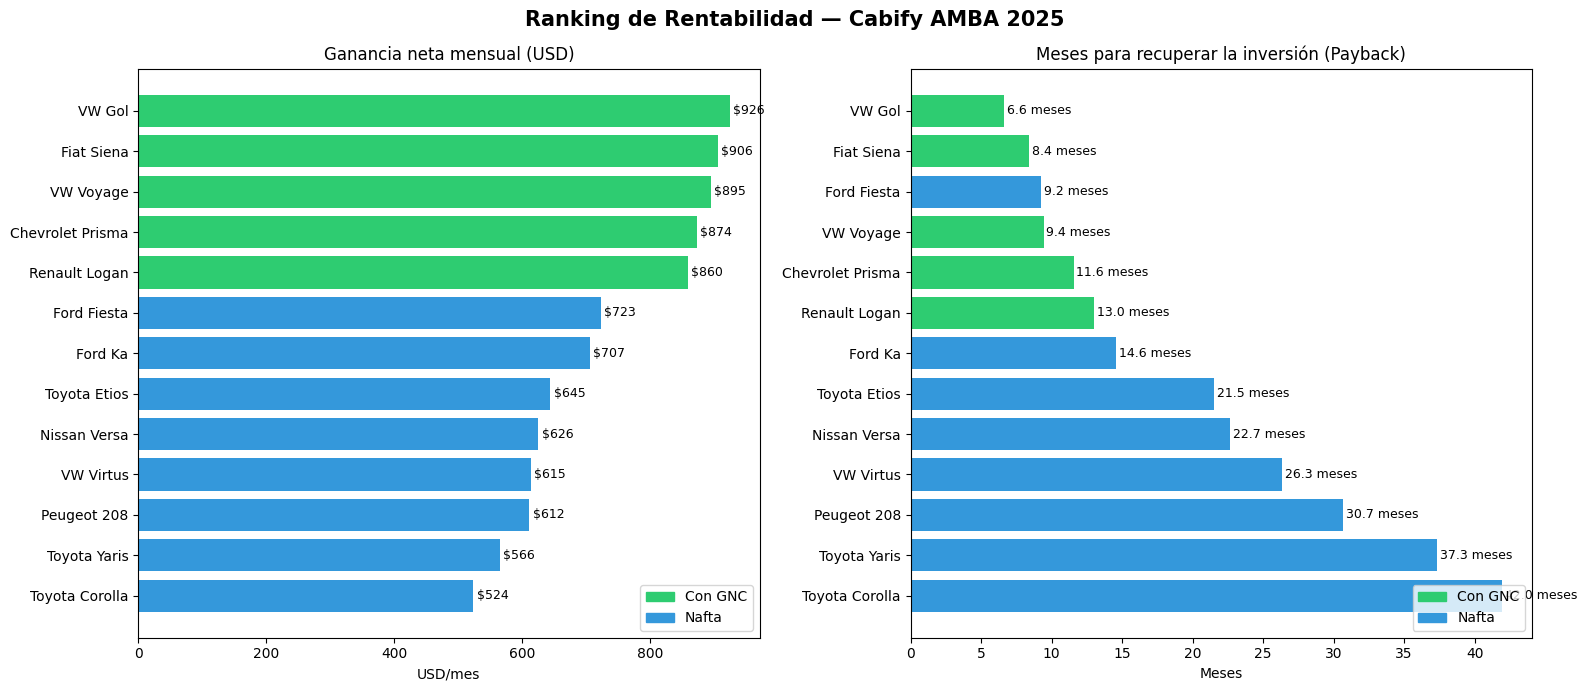

Gráfico guardado.


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Ranking de Rentabilidad — Cabify AMBA 2025", fontsize=15, fontweight="bold")

df_plot = df_resultados.sort_values("ganancia_neta_usd", ascending=True)
colores = ["#2ecc71" if df_resultados.loc[m, "tiene_gnc"] else "#3498db" for m in df_plot.index]

# 1. Ganancia neta mensual en USD
bars = axes[0].barh(df_plot.index, df_plot["ganancia_neta_usd"], color=colores)
axes[0].set_title("Ganancia neta mensual (USD)", fontsize=12)
axes[0].set_xlabel("USD/mes")
for i, v in enumerate(df_plot["ganancia_neta_usd"]):
    axes[0].text(v + 5, i, f"${v:,.0f}", va="center", fontsize=9)

patch_gnc = mpatches.Patch(color="#2ecc71", label="Con GNC")
patch_nafta = mpatches.Patch(color="#3498db", label="Nafta")
axes[0].legend(handles=[patch_gnc, patch_nafta], loc="lower right")

# 2. Payback period en meses
df_plot2 = df_resultados.sort_values("payback_meses", ascending=False)
colores2 = ["#2ecc71" if df_resultados.loc[m, "tiene_gnc"] else "#3498db" for m in df_plot2.index]
axes[1].barh(df_plot2.index, df_plot2["payback_meses"], color=colores2)
axes[1].set_title("Meses para recuperar la inversión (Payback)", fontsize=12)
axes[1].set_xlabel("Meses")
for i, v in enumerate(df_plot2["payback_meses"]):
    axes[1].text(v + 0.2, i, f"{v:.1f} meses", va="center", fontsize=9)
axes[1].legend(handles=[patch_gnc, patch_nafta], loc="lower right")

plt.tight_layout()
plt.savefig("../reports/figures/02_ranking_rentabilidad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado.")

### Interpretación del ranking

El gráfico revela que la rentabilidad depende de dos factores principales:

1. **Combustible:** los autos con GNC reducen el costo de combustible en ~$250.000 ARS/mes
   respecto a los de nafta, lo que los lleva automáticamente al tope del ranking.

2. **Precio de compra:** determina la amortización mensual. Un auto más barato
   amortiza menos por mes, lo que mejora la ganancia neta independientemente
   del combustible. Ejemplo: el Ford Fiesta (nafta, $6.683 USD) supera en
   rentabilidad a autos más caros como el Toyota Corolla ($22.000 USD).

**Conclusión:** el auto ideal para Cabify combina bajo precio de entrada con GNC.
El VW Gol lidera el ranking por exactamente esa combinación.